In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(
    r"C:\Users\Rahul Tripathi\Desktop\Nassau_Candy_Profitability\data\Nassau Candy Distributor.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10194, 18)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']

Data Types:
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDuplicate Order IDs:", df["Order ID"].duplicated().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

Duplicate Rows: 0

Duplicate Order IDs: 1645


In [6]:
display(df.describe())

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [8]:
# Convert dates safely
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date Range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

print("\nInvalid Order Dates:", df["Order Date"].isna().sum())
print("Invalid Ship Dates:", df["Ship Date"].isna().sum())

Order Date Range:
2024-01-02 00:00:00 to 2025-12-12 00:00:00

Ship Date Range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00

Invalid Order Dates: 6064
Invalid Ship Dates: 0


C:\Users\Rahul Tripathi\AppData\Local\Temp\ipykernel_10740\249584953.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


In [9]:
print("Divisions:")
print(df["Division"].value_counts())

print("\nRegions:")
print(df["Region"].value_counts())

print("\nShip Modes:")
print(df["Ship Mode"].value_counts())

print("\nUnique Products:", df["Product Name"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())

Divisions:
Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

Regions:
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

Ship Modes:
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

Unique Products: 15
Unique Customers: 5044


In [10]:
df["Calculated_Profit"] = df["Sales"] - df["Cost"]

df["Profit_Difference"] = (
    df["Gross Profit"] - df["Calculated_Profit"]
)

print("Maximum Profit Difference:",
      df["Profit_Difference"].abs().max())

print("Rows with Profit Mismatch:",
      (df["Profit_Difference"].abs() > 0.01).sum())

Maximum Profit Difference: 7.105427357601002e-15
Rows with Profit Mismatch: 0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    r"C:\Users\Rahul Tripathi\Desktop\Nassau_Candy_Profitability\data\Nassau Candy Distributor.csv"
)

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print("Dataset loaded:", df.shape)

Dataset loaded: (10194, 18)


C:\Users\Rahul Tripathi\AppData\Local\Temp\ipykernel_9356\4014922188.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


In [3]:
numeric_cols = ["Sales", "Units", "Gross Profit", "Cost"]

print("Negative values:")
for col in numeric_cols:
    print(col, ":", (df[col] < 0).sum())

print("\nZero values:")
for col in numeric_cols:
    print(col, ":", (df[col] == 0).sum())

Negative values:
Sales : 0
Units : 0
Gross Profit : 0
Cost : 0

Zero values:
Sales : 0
Units : 0
Gross Profit : 0
Cost : 0


In [4]:
print("Sales <= 0:", (df["Sales"] <= 0).sum())
print("Cost < 0:", (df["Cost"] < 0).sum())
print("Units <= 0:", (df["Units"] <= 0).sum())
print("Gross Profit < 0:", (df["Gross Profit"] < 0).sum())

Sales <= 0: 0
Cost < 0: 0
Units <= 0: 0
Gross Profit < 0: 0


In [5]:
# Gross Margin %
df["Gross_Margin"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

# Profit per Unit
df["Profit_Per_Unit"] = (
    df["Gross Profit"] / df["Units"]
)

# Revenue Contribution %
df["Revenue_Contribution"] = (
    df["Sales"] / df["Sales"].sum()
) * 100

# Profit Contribution %
df["Profit_Contribution"] = (
    df["Gross Profit"] / df["Gross Profit"].sum()
) * 100

# Time features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Gross_Margin,Profit_Per_Unit,Revenue_Contribution,Profit_Contribution,Year,Month,Month_Name
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,64.923077,2.11,0.004584,0.004516,2024.0,3.0,March
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2,4.90,2.60,65.333333,2.45,0.005290,0.005244,2024.0,4.0,April
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.47,3.00,71.346705,2.49,0.007384,0.007994,2024.0,4.0,April
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.50,3.30,69.444444,2.50,0.007617,0.008026,2024.0,4.0,April
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,65.333333,2.45,0.007935,0.007866,2024.0,5.0,May


In [6]:
display(
    df[
        [
            "Product Name",
            "Sales",
            "Units",
            "Gross Profit",
            "Cost",
            "Gross_Margin",
            "Profit_Per_Unit",
            "Revenue_Contribution",
            "Profit_Contribution"
        ]
    ].head(10)
)

,Product Name,Sales,Units,Gross Profit,Cost,Gross_Margin,Profit_Per_Unit,Revenue_Contribution,Profit_Contribution
0,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11,0.004584,0.004516
1,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45,0.005290,0.005244
2,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49,0.007384,0.007994
3,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50,0.007617,0.008026
4,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,0.007935,0.007866
5,Wonka Bar -Scrumdiddlyumptious,32.40,9,22.50,9.90,69.444444,2.50,0.022852,0.024079
6,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45,0.005290,0.005244
7,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,64.923077,2.11,0.006877,0.006774
8,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,71.346705,2.49,0.004923,0.005329
9,Wonka Bar - Milk Chocolate,13.00,4,8.44,4.56,64.923077,2.11,0.009169,0.009032


In [7]:
total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
total_units = df["Units"].sum()
overall_margin = (total_profit / total_sales) * 100

print("========== OVERALL BUSINESS KPIs ==========")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Cost        : ${total_cost:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Total Units       : {total_units:,.0f}")
print(f"Gross Margin      : {overall_margin:.2f}%")
print(f"Profit per Unit   : ${total_profit / total_units:.2f}")

========== OVERALL BUSINESS KPIs ==========
Total Sales       : $141,783.63
Total Cost        : $48,340.83
Total Gross Profit: $93,442.80
Total Units       : 38,654
Gross Margin      : 65.91%
Profit per Unit   : $2.42


In [8]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNew Columns:")
print([
    "Gross_Margin",
    "Profit_Per_Unit",
    "Revenue_Contribution",
    "Profit_Contribution",
    "Year",
    "Month",
    "Month_Name"
])

Final Shape: (10194, 25)

Missing Values:
Row ID                     0
Order ID                   0
Order Date              6064
Ship Date                  0
Ship Mode                  0
Customer ID                0
Country/Region             0
City                       0
State/Province             0
Postal Code                0
Division                   0
Region                     0
Product ID                 0
Product Name               0
Sales                      0
Units                      0
Gross Profit               0
Cost                       0
Gross_Margin               0
Profit_Per_Unit            0
Revenue_Contribution       0
Profit_Contribution        0
Year                    6064
Month                   6064
Month_Name              6064
dtype: int64

New Columns:
['Gross_Margin', 'Profit_Per_Unit', 'Revenue_Contribution', 'Profit_Contribution', 'Year', 'Month', 'Month_Name']


In [9]:
display(
    df[["Sales", "Cost", "Gross Profit", "Units",
        "Gross_Margin", "Profit_Per_Unit"]].describe().round(2)
)

,Sales,Cost,Gross Profit,Units,Gross_Margin,Profit_Per_Unit
count,10194.00,10194.00,10194.00,10194.00,10194.00,10194.00
mean,13.91,4.74,9.17,3.79,66.51,2.41
std,11.34,5.06,6.64,2.23,6.72,0.81
min,1.25,0.60,0.25,1.00,7.69,0.25
25%,7.20,2.40,4.90,2.00,65.33,2.40
50%,10.80,3.60,7.47,3.00,66.67,2.45
75%,18.00,5.70,12.25,5.00,69.44,2.49
max,260.00,130.00,130.00,14.00,80.00,10.00


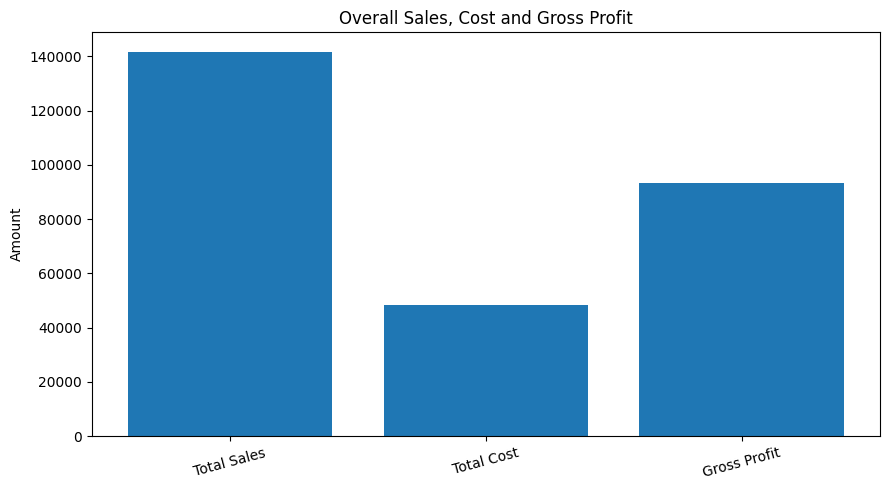

In [10]:
kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Cost": df["Cost"].sum(),
    "Gross Profit": df["Gross Profit"].sum()
}

plt.figure(figsize=(9, 5))
plt.bar(kpis.keys(), kpis.values())
plt.title("Overall Sales, Cost and Gross Profit")
plt.ylabel("Amount")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

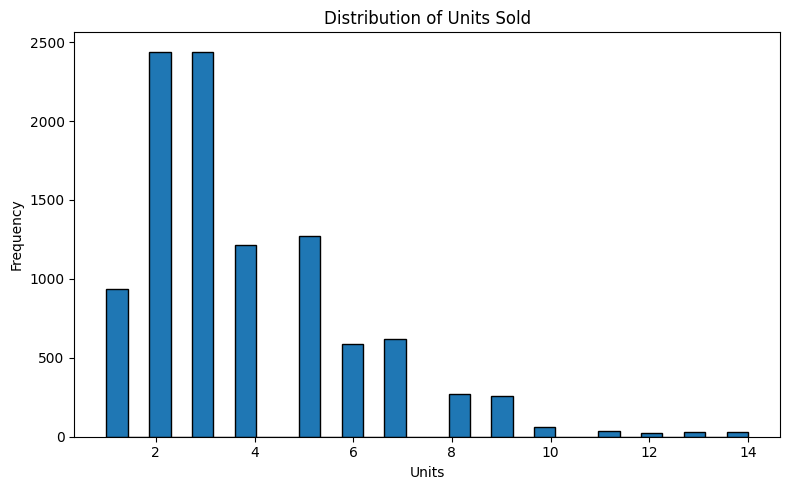

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["Units"], bins=30, edgecolor="black")
plt.title("Distribution of Units Sold")
plt.xlabel("Units")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

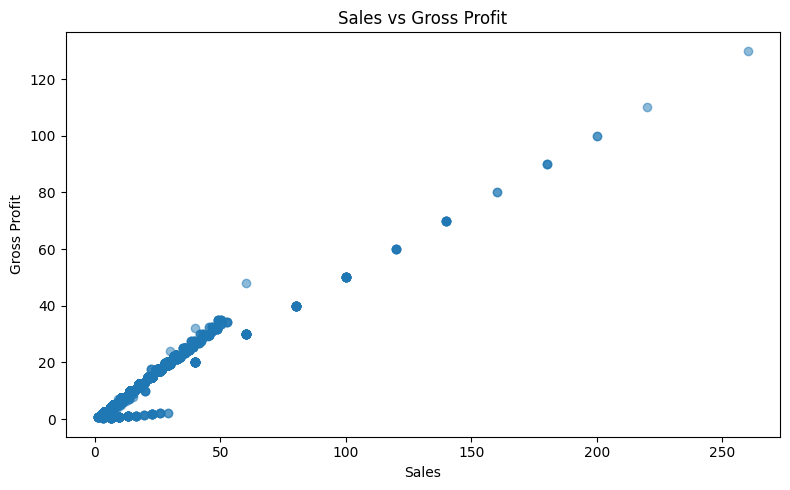

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Gross Profit"], alpha=0.5)
plt.title("Sales vs Gross Profit")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

In [13]:
division_summary = df.groupby("Division").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Units=("Units", "sum")
)

division_summary["Gross_Margin_%"] = (
    division_summary["Total_Profit"] /
    division_summary["Total_Sales"] * 100
)

display(division_summary.round(2))

,Total_Sales,Total_Profit,Total_Cost,Total_Units,Gross_Margin_%
Division,,,,,
Chocolate,131692.90,88824.62,42868.28,37275,67.45
Other,9663.25,4333.45,5329.80,1242,44.84
Sugar,427.48,284.73,142.75,137,66.61


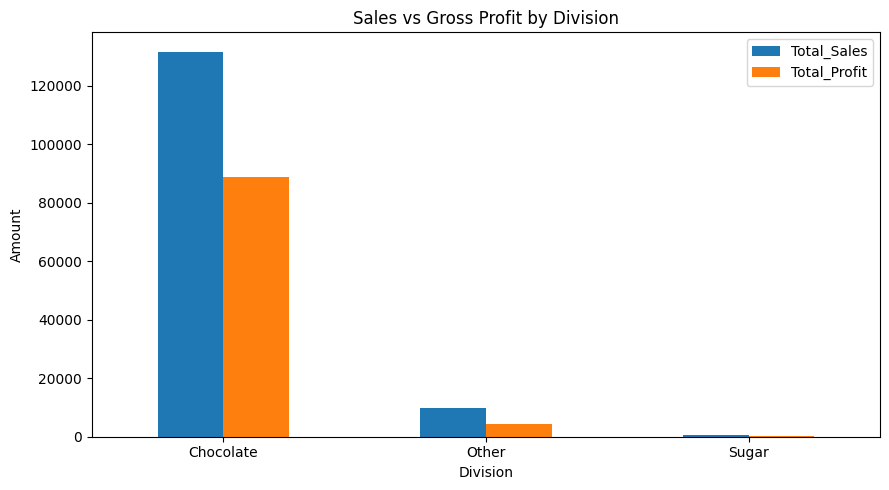

In [14]:
division_summary[["Total_Sales", "Total_Profit"]].plot(
    kind="bar", figsize=(9, 5)
)

plt.title("Sales vs Gross Profit by Division")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

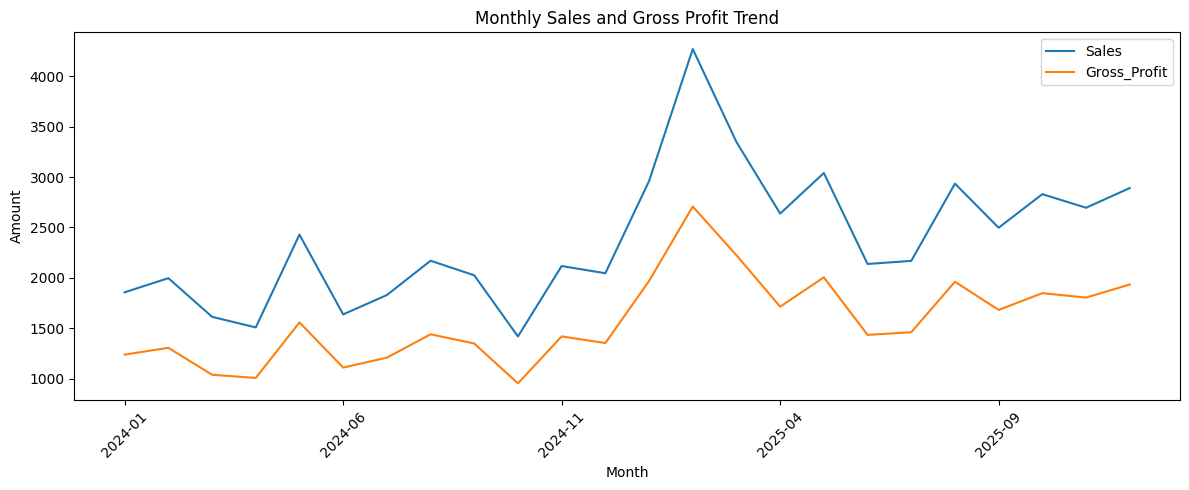

In [15]:
monthly_summary = df.groupby(
    df["Order Date"].dt.to_period("M")
).agg(
    Sales=("Sales", "sum"),
    Gross_Profit=("Gross Profit", "sum")
)

monthly_summary.index = monthly_summary.index.astype(str)

monthly_summary.plot(figsize=(12, 5))
plt.title("Monthly Sales and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
product_summary = df.groupby(
    ["Product Name", "Division"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Units=("Units", "sum")
).reset_index()

product_summary["Gross_Margin_%"] = (
    product_summary["Total_Profit"] /
    product_summary["Total_Sales"].replace(0, np.nan) * 100
)

product_summary["Profit_Per_Unit"] = (
    product_summary["Total_Profit"] /
    product_summary["Total_Units"].replace(0, np.nan)
)

product_summary = product_summary.replace(
    [np.inf, -np.inf], np.nan
)

print("Unique Product-Division combinations:",
      len(product_summary))

display(product_summary.head())

Unique Product-Division combinations: 15


,Product Name,Division,Total_Sales,Total_Profit,Total_Cost,Total_Units,Gross_Margin_%,Profit_Per_Unit
0,Everlasting Gobstopper,Sugar,130.00,104.00,26.0,13,80.000000,8.00
1,Fizzy Lifting Drinks,Sugar,78.75,47.25,31.5,21,60.000000,2.25
2,Fun Dip,Sugar,12.00,4.80,7.2,8,40.000000,0.60
3,Hair Toffee,Sugar,76.50,59.50,17.0,17,77.777778,3.50
4,Kazookles,Other,1205.75,92.75,1113.0,371,7.692308,0.25


,Product Name,Division,Total_Sales,Total_Profit,Gross_Margin_%
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.44
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.33
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.92
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.35
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.67
6,Lickable Wallpaper,Other,7860.00,3930.00,50.00
14,Wonka Gum,Other,597.50,310.70,52.00
0,Everlasting Gobstopper,Sugar,130.00,104.00,80.00
4,Kazookles,Other,1205.75,92.75,7.69
3,Hair Toffee,Sugar,76.50,59.50,77.78


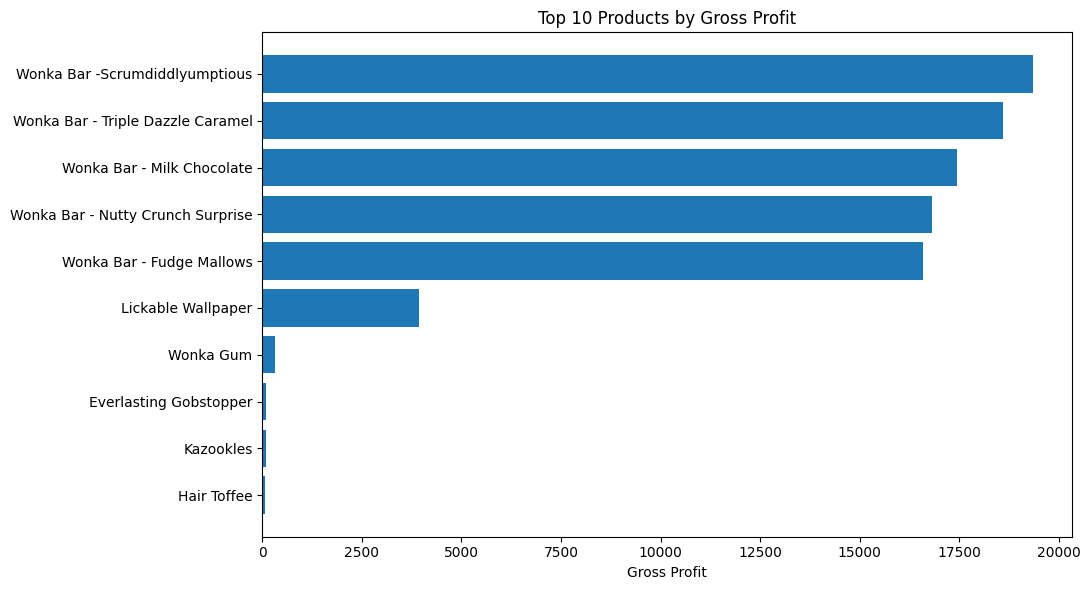

In [17]:
top_profit = product_summary.nlargest(10, "Total_Profit")

display(
    top_profit[
        ["Product Name", "Division", "Total_Sales",
         "Total_Profit", "Gross_Margin_%"]
    ].round(2)
)

plt.figure(figsize=(11, 6))
plt.barh(top_profit["Product Name"], top_profit["Total_Profit"])
plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Gross Profit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,Product Name,Division,Total_Sales,Total_Profit,Gross_Margin_%
0,Everlasting Gobstopper,Sugar,130.00,104.00,80.00
3,Hair Toffee,Sugar,76.50,59.50,77.78
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.35
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.44
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.67
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.33
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.92
5,Laffy Taffy,Sugar,53.73,33.48,62.31
1,Fizzy Lifting Drinks,Sugar,78.75,47.25,60.00
14,Wonka Gum,Other,597.50,310.70,52.00


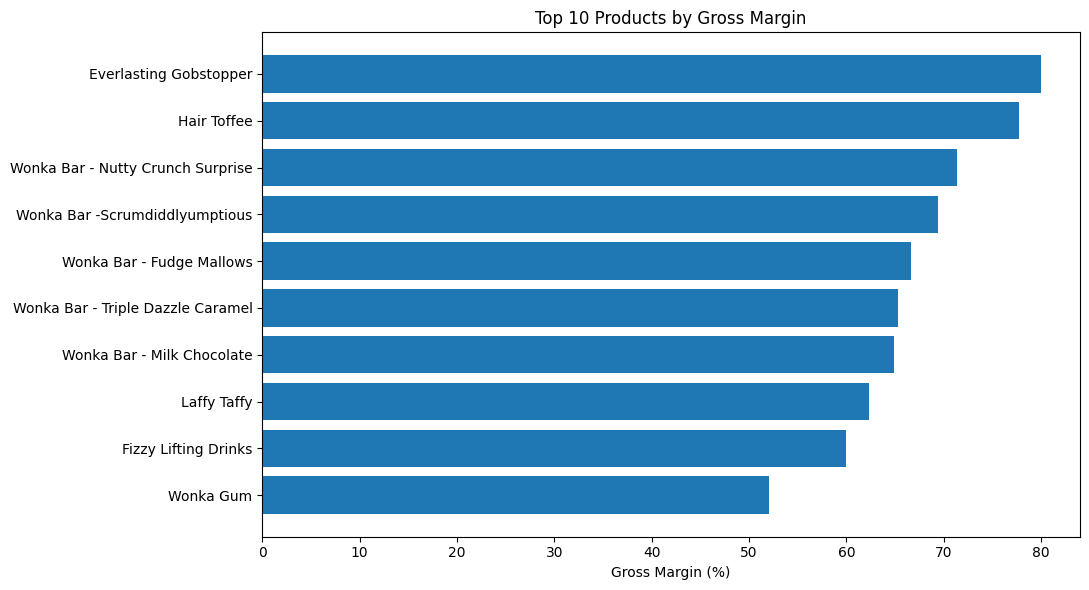

In [18]:
valid_products = product_summary[
    (product_summary["Total_Sales"] > 0) &
    (product_summary["Total_Profit"].notna())
]

top_margin = valid_products.nlargest(10, "Gross_Margin_%")

display(
    top_margin[
        ["Product Name", "Division", "Total_Sales",
         "Total_Profit", "Gross_Margin_%"]
    ].round(2)
)

plt.figure(figsize=(11, 6))
plt.barh(top_margin["Product Name"], top_margin["Gross_Margin_%"])
plt.title("Top 10 Products by Gross Margin")
plt.xlabel("Gross Margin (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
sales_threshold = product_summary["Total_Sales"].median()
margin_threshold = valid_products["Gross_Margin_%"].median()

high_sales_low_margin = product_summary[
    (product_summary["Total_Sales"] >= sales_threshold) &
    (product_summary["Gross_Margin_%"] < margin_threshold)
].sort_values("Total_Sales", ascending=False)

print("High Sales + Below-Median Margin Products:")
display(high_sales_low_margin.round(2))

High Sales + Below-Median Margin Products:


,Product Name,Division,Total_Sales,Total_Profit,Total_Cost,Total_Units,Gross_Margin_%,Profit_Per_Unit
6,Lickable Wallpaper,Other,7860.00,3930.00,3930.0,393,50.00,10.00
4,Kazookles,Other,1205.75,92.75,1113.0,371,7.69,0.25
14,Wonka Gum,Other,597.50,310.70,286.8,478,52.00,0.65


In [20]:
def classify_product(row):
    if row["Total_Sales"] >= sales_threshold and row["Total_Profit"] >= product_summary["Total_Profit"].median():
        return "High Sales - High Profit"
    elif row["Total_Sales"] >= sales_threshold and row["Gross_Margin_%"] < margin_threshold:
        return "High Sales - Low Margin"
    elif row["Total_Sales"] < sales_threshold and row["Total_Profit"] < product_summary["Total_Profit"].median():
        return "Low Sales - Low Profit"
    else:
        return "Other"

product_summary["Profitability_Category"] = product_summary.apply(
    classify_product, axis=1
)

print(product_summary["Profitability_Category"].value_counts())

display(
    product_summary.sort_values("Total_Profit", ascending=False).head(15)
)

Profitability_Category
High Sales - High Profit    7
Low Sales - Low Profit      6
Other                       1
High Sales - Low Margin     1
Name: count, dtype: int64


,Product Name,Division,Total_Sales,Total_Profit,Total_Cost,Total_Units,Gross_Margin_%,Profit_Per_Unit,Profitability_Category
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,8517.30,7743,69.444444,2.50,High Sales - High Profit
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,9874.80,7596,65.333333,2.45,High Sales - High Profit
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11,High Sales - High Profit
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,6755.00,6755,71.346705,2.49,High Sales - High Profit
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,8296.80,6914,66.666667,2.40,High Sales - High Profit
6,Lickable Wallpaper,Other,7860.00,3930.00,3930.00,393,50.000000,10.00,High Sales - High Profit
14,Wonka Gum,Other,597.50,310.70,286.80,478,52.000000,0.65,High Sales - High Profit
0,Everlasting Gobstopper,Sugar,130.00,104.00,26.00,13,80.000000,8.00,Other
4,Kazookles,Other,1205.75,92.75,1113.00,371,7.692308,0.25,High Sales - Low Margin
3,Hair Toffee,Sugar,76.50,59.50,17.00,17,77.777778,3.50,Low Sales - Low Profit


In [21]:
total_revenue = product_summary["Total_Sales"].sum()
total_profit = product_summary["Total_Profit"].sum()

product_summary["Revenue_Contribution_%"] = (
    product_summary["Total_Sales"] / total_revenue * 100
)

product_summary["Profit_Contribution_%"] = (
    product_summary["Total_Profit"] / total_profit * 100
)

display(
    product_summary.sort_values(
        "Profit_Contribution_%", ascending=False
    )[
        ["Product Name", "Division", "Total_Sales", "Total_Profit",
         "Revenue_Contribution_%", "Profit_Contribution_%"]
    ].head(15).round(2)
)

,Product Name,Division,Total_Sales,Total_Profit,Revenue_Contribution_%,Profit_Contribution_%
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,19.66,20.72
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,20.09,19.92
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,18.95,18.67
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,16.63,18.00
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,17.56,17.76
6,Lickable Wallpaper,Other,7860.00,3930.00,5.54,4.21
14,Wonka Gum,Other,597.50,310.70,0.42,0.33
0,Everlasting Gobstopper,Sugar,130.00,104.00,0.09,0.11
4,Kazookles,Other,1205.75,92.75,0.85,0.10
3,Hair Toffee,Sugar,76.50,59.50,0.05,0.06


In [22]:
division_summary = df.groupby("Division").agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum"),
    Average_Order_Margin=("Gross_Margin", "mean")
).reset_index()

division_summary["Gross_Margin_%"] = (
    division_summary["Total_Profit"] /
    division_summary["Total_Sales"] * 100
)

division_summary["Profit_Per_Unit"] = (
    division_summary["Total_Profit"] /
    division_summary["Total_Units"]
)

display(division_summary.round(2))

,Division,Total_Sales,Total_Cost,Total_Profit,Total_Units,Average_Order_Margin,Gross_Margin_%,Profit_Per_Unit
0,Chocolate,131692.90,42868.28,88824.62,37275,67.46,67.45,2.38
1,Other,9663.25,5329.80,4333.45,1242,37.67,44.84,3.49
2,Sugar,427.48,142.75,284.73,137,57.69,66.61,2.08


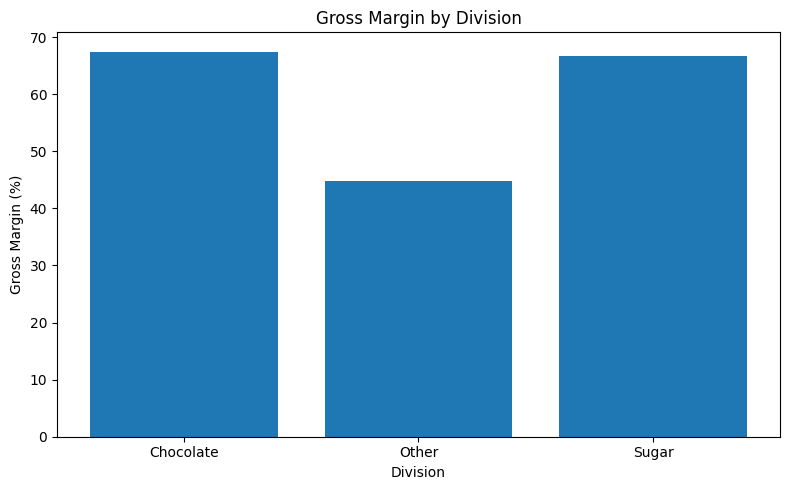

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(
    division_summary["Division"],
    division_summary["Gross_Margin_%"]
)
plt.title("Gross Margin by Division")
plt.xlabel("Division")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [24]:
pareto_profit = product_summary.sort_values(
    "Total_Profit", ascending=False
).copy()

pareto_profit["Cumulative_Profit"] = (
    pareto_profit["Total_Profit"].cumsum()
)

pareto_profit["Cumulative_Profit_%"] = (
    pareto_profit["Cumulative_Profit"] /
    pareto_profit["Total_Profit"].sum() * 100
)

display(pareto_profit[
    ["Product Name", "Total_Profit", "Cumulative_Profit_%"]
].head(15).round(2))

products_for_80_profit = (
    pareto_profit["Cumulative_Profit_%"] < 80
).sum() + 1

print("Products needed to reach approximately 80% of profit:",
      products_for_80_profit)

print("Total unique product entries:", len(pareto_profit))
print("Share of products:", round(
    products_for_80_profit / len(pareto_profit) * 100, 2
), "%")

,Product Name,Total_Profit,Cumulative_Profit_%
13,Wonka Bar -Scrumdiddlyumptious,19357.50,20.72
12,Wonka Bar - Triple Dazzle Caramel,18610.20,40.63
10,Wonka Bar - Milk Chocolate,17443.37,59.30
11,Wonka Bar - Nutty Crunch Surprise,16819.95,77.30
9,Wonka Bar - Fudge Mallows,16593.60,95.06
6,Lickable Wallpaper,3930.00,99.26
14,Wonka Gum,310.70,99.60
0,Everlasting Gobstopper,104.00,99.71
4,Kazookles,92.75,99.81
3,Hair Toffee,59.50,99.87


Products needed to reach approximately 80% of profit: 5
Total unique product entries: 15
Share of products: 33.33 %


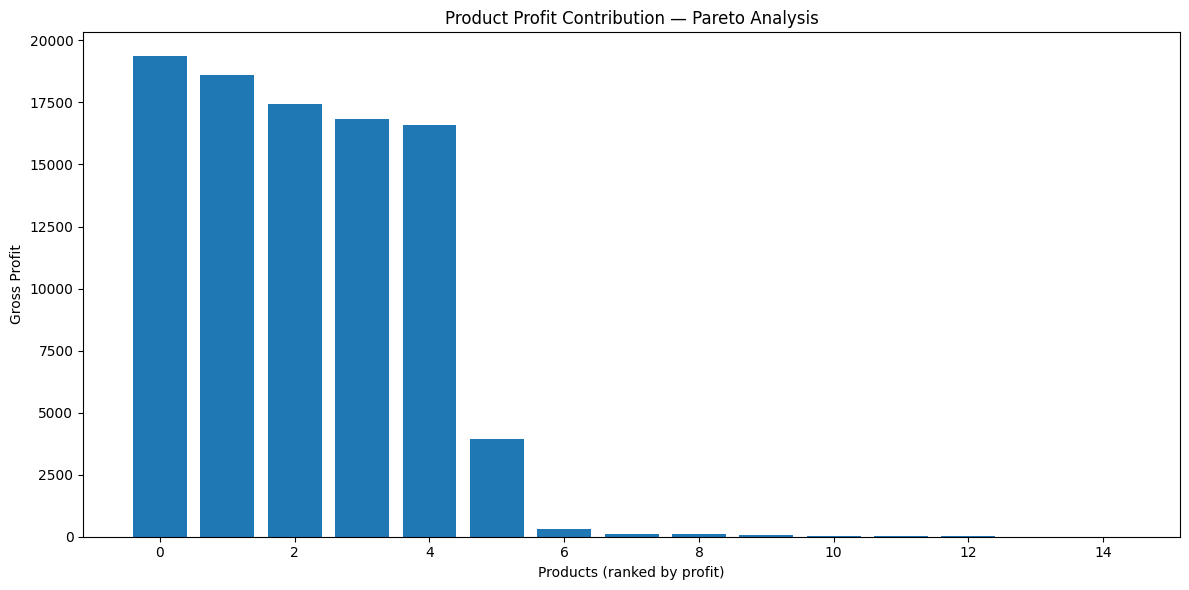

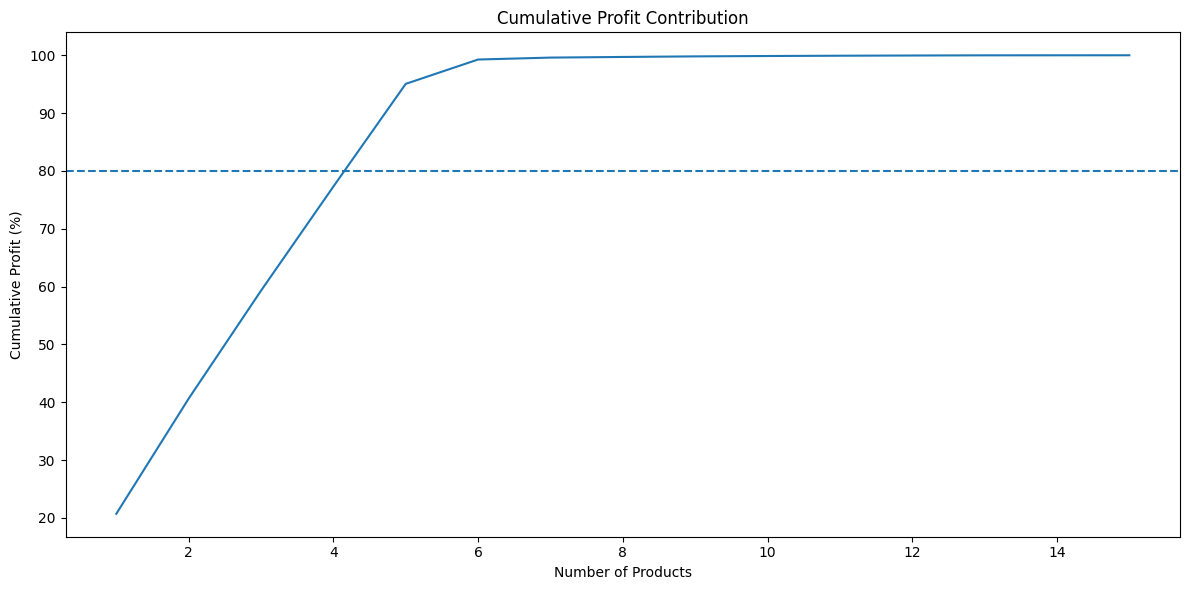

In [25]:
plt.figure(figsize=(12, 6))

plt.bar(
    range(len(pareto_profit)),
    pareto_profit["Total_Profit"]
)

plt.title("Product Profit Contribution — Pareto Analysis")
plt.xlabel("Products (ranked by profit)")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(pareto_profit) + 1),
    pareto_profit["Cumulative_Profit_%"]
)

plt.axhline(80, linestyle="--")
plt.title("Cumulative Profit Contribution")
plt.xlabel("Number of Products")
plt.ylabel("Cumulative Profit (%)")
plt.tight_layout()
plt.show()

In [26]:
pareto_revenue = product_summary.sort_values(
    "Total_Sales", ascending=False
).copy()

pareto_revenue["Cumulative_Revenue_%"] = (
    pareto_revenue["Total_Sales"].cumsum() /
    pareto_revenue["Total_Sales"].sum() * 100
)

products_for_80_revenue = (
    pareto_revenue["Cumulative_Revenue_%"] < 80
).sum() + 1

print("Products needed to reach approximately 80% of revenue:",
      products_for_80_revenue)

print("Total products:", len(pareto_revenue))

display(pareto_revenue[
    ["Product Name", "Total_Sales", "Cumulative_Revenue_%"]
].head(15).round(2))

Products needed to reach approximately 80% of revenue: 5
Total products: 15


,Product Name,Total_Sales,Cumulative_Revenue_%
12,Wonka Bar - Triple Dazzle Caramel,28485.00,20.09
13,Wonka Bar -Scrumdiddlyumptious,27874.80,39.75
10,Wonka Bar - Milk Chocolate,26867.75,58.70
9,Wonka Bar - Fudge Mallows,24890.40,76.26
11,Wonka Bar - Nutty Crunch Surprise,23574.95,92.88
6,Lickable Wallpaper,7860.00,98.43
4,Kazookles,1205.75,99.28
14,Wonka Gum,597.50,99.70
0,Everlasting Gobstopper,130.00,99.79
1,Fizzy Lifting Drinks,78.75,99.85


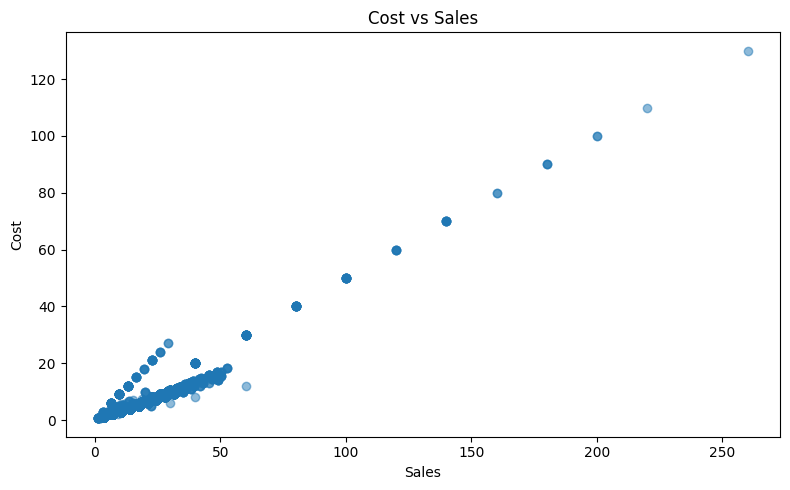

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Cost"], alpha=0.5)
plt.title("Cost vs Sales")
plt.xlabel("Sales")
plt.ylabel("Cost")
plt.tight_layout()
plt.show()

In [28]:
product_summary["Margin_Risk"] = np.select(
    [
        product_summary["Gross_Margin_%"] < 10,
        product_summary["Gross_Margin_%"] < 20
    ],
    [
        "High Risk: Margin Below 10%",
        "Medium Risk: Margin 10–20%"
    ],
    default="Healthy: Margin 20% or Above"
)

display(
    product_summary[
        ["Product Name", "Division", "Total_Sales",
         "Total_Profit", "Gross_Margin_%", "Margin_Risk"]
    ].sort_values("Gross_Margin_%").head(20).round(2)
)

,Product Name,Division,Total_Sales,Total_Profit,Gross_Margin_%,Margin_Risk
4,Kazookles,Other,1205.75,92.75,7.69,High Risk: Margin Below 10%
2,Fun Dip,Sugar,12.00,4.80,40.00,Healthy: Margin 20% or Above
7,Nerds,Sugar,15.00,7.00,46.67,Healthy: Margin 20% or Above
8,SweeTARTS,Sugar,61.50,28.70,46.67,Healthy: Margin 20% or Above
6,Lickable Wallpaper,Other,7860.00,3930.00,50.00,Healthy: Margin 20% or Above
14,Wonka Gum,Other,597.50,310.70,52.00,Healthy: Margin 20% or Above
1,Fizzy Lifting Drinks,Sugar,78.75,47.25,60.00,Healthy: Margin 20% or Above
5,Laffy Taffy,Sugar,53.73,33.48,62.31,Healthy: Margin 20% or Above
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.92,Healthy: Margin 20% or Above
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.33,Healthy: Margin 20% or Above


Margin_Risk
Healthy: Margin 20% or Above    14
High Risk: Margin Below 10%      1
Name: count, dtype: int64

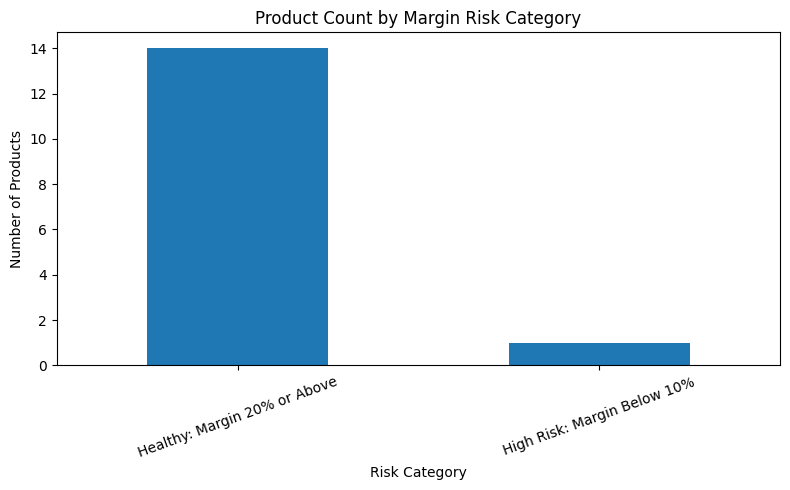

In [29]:
risk_counts = product_summary["Margin_Risk"].value_counts()

display(risk_counts)

risk_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Product Count by Margin Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,Sales,Gross_Profit,Gross_Margin_%
Order Date,,,
2025-01,2960.67,1969.07,66.51
2025-02,4270.98,2707.84,63.40
2025-03,3348.48,2224.70,66.44
2025-04,2637.80,1714.10,64.98
2025-05,3040.75,2005.43,65.95
2025-06,2137.95,1434.26,67.09
2025-07,2168.48,1460.30,67.34
2025-08,2935.21,1961.66,66.83
2025-09,2497.72,1682.00,67.34


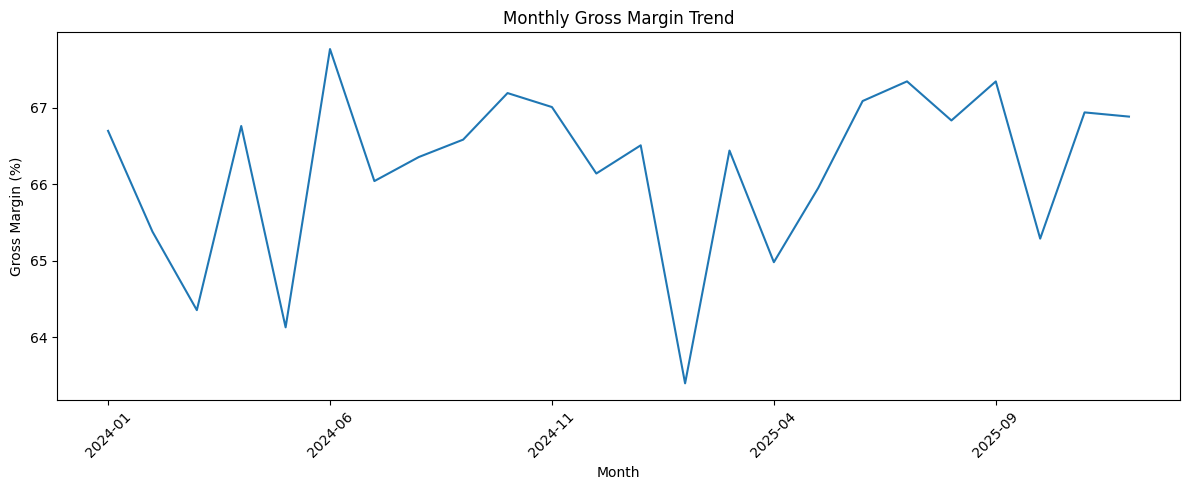

In [30]:
monthly_margin = df.groupby(
    df["Order Date"].dt.to_period("M")
).agg(
    Sales=("Sales", "sum"),
    Gross_Profit=("Gross Profit", "sum")
)

monthly_margin["Gross_Margin_%"] = (
    monthly_margin["Gross_Profit"] /
    monthly_margin["Sales"] * 100
)

monthly_margin.index = monthly_margin.index.astype(str)

display(monthly_margin.tail(12).round(2))

monthly_margin["Gross_Margin_%"].plot(figsize=(12, 5))
plt.title("Monthly Gross Margin Trend")
plt.xlabel("Month")
plt.ylabel("Gross Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Recreate validation columns
df["Calculated_Profit"] = df["Sales"] - df["Cost"]
df["Profit_Difference"] = df["Gross Profit"] - df["Calculated_Profit"]

# Final validation
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Profit mismatches:", (df["Profit_Difference"].abs() > 0.01).sum())
print("Invalid dates:", df["Order Date"].isna().sum() + df["Ship Date"].isna().sum())
print("Product summary shape:", product_summary.shape)
print("Division summary shape:", division_summary.shape)

Dataset shape: (10194, 27)
Duplicate rows: 0
Missing values: 24256
Profit mismatches: 0
Invalid dates: 6064
Product summary shape: (15, 12)
Division summary shape: (3, 8)


In [33]:
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Save all currently open Matplotlib figures
for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    fig.savefig(
        output_dir / f"analysis_chart_{i}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Charts saved in:", output_dir.resolve())
print("Charts exported:", len(plt.get_fignums()))

Charts saved in: C:\Users\Rahul Tripathi\Desktop\Nassau_Candy_Profitability\outputs
Charts exported: 0


In [34]:
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

figures = plt.get_fignums()

for i, fig_num in enumerate(figures, start=1):
    fig = plt.figure(fig_num)
    fig.savefig(
        output_dir / f"analysis_chart_{i}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Charts exported:", len(figures))
print("Saved to:", output_dir.resolve())

Charts exported: 0
Saved to: C:\Users\Rahul Tripathi\Desktop\Nassau_Candy_Profitability\outputs


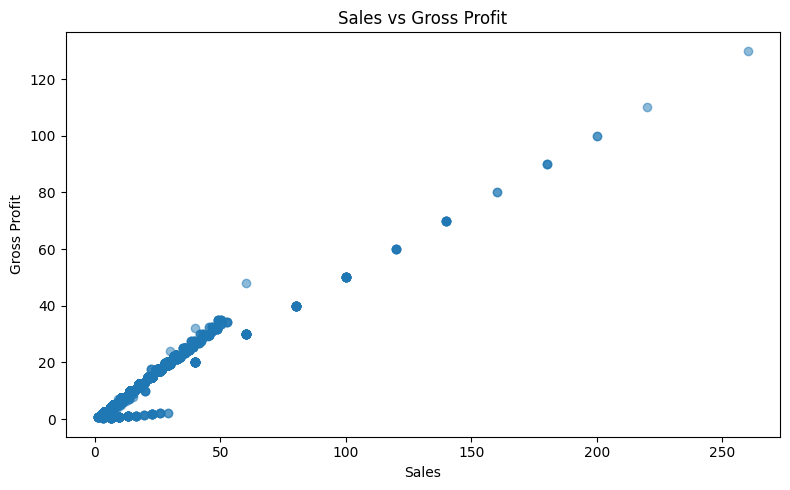

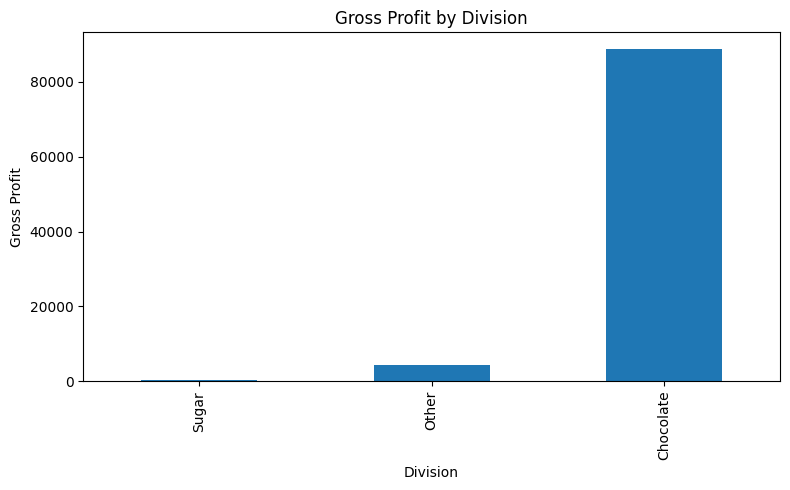

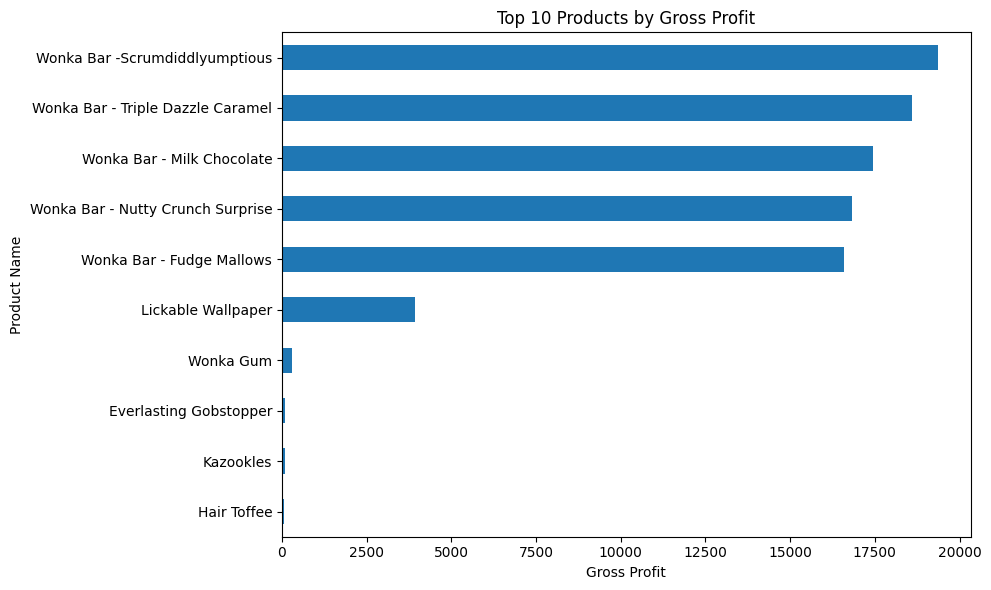

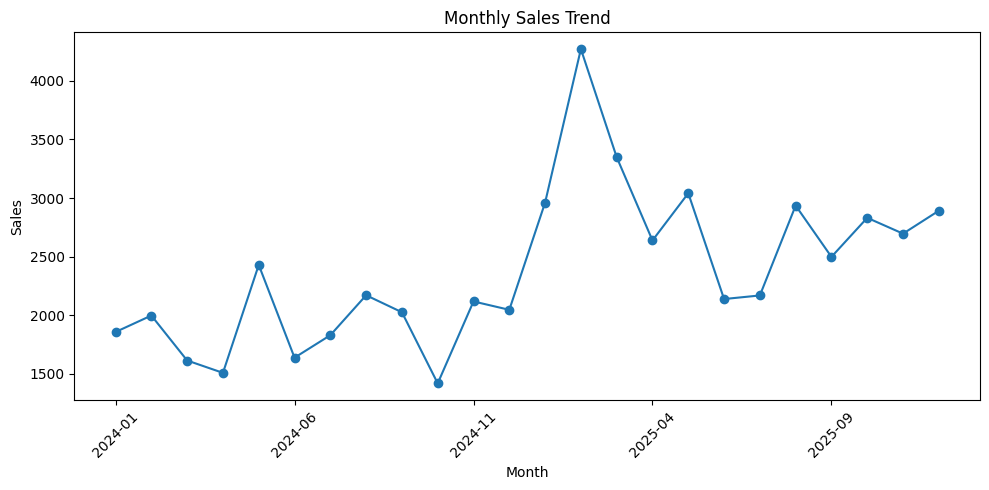

Charts saved: 4
Location: C:\Users\Rahul Tripathi\Desktop\Nassau_Candy_Profitability\outputs
Files: ['monthly_sales_trend.png', 'profit_by_division.png', 'sales_vs_profit.png', 'top_10_products.png']


In [35]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Sales vs Gross Profit
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Sales"], df["Gross Profit"], alpha=0.5)
ax.set_title("Sales vs Gross Profit")
ax.set_xlabel("Sales")
ax.set_ylabel("Gross Profit")
fig.tight_layout()
fig.savefig(output_dir / "sales_vs_profit.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# 2. Gross Profit by Division
division_chart = df.groupby("Division")["Gross Profit"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
division_chart.plot(kind="bar", ax=ax)
ax.set_title("Gross Profit by Division")
ax.set_xlabel("Division")
ax.set_ylabel("Gross Profit")
fig.tight_layout()
fig.savefig(output_dir / "profit_by_division.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# 3. Top 10 Products by Gross Profit
top_products = (
    df.groupby("Product Name")["Gross Profit"]
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
top_products.plot(kind="barh", ax=ax)
ax.set_title("Top 10 Products by Gross Profit")
ax.set_xlabel("Gross Profit")
fig.tight_layout()
fig.savefig(output_dir / "top_10_products.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# 4. Monthly Sales Trend
monthly_sales = (
    df.dropna(subset=["Order Date"])
    .groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind="line", marker="o", ax=ax)
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(output_dir / "monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Charts saved:", len(list(output_dir.glob("*.png"))))
print("Location:", output_dir.resolve())
print("Files:", [p.name for p in output_dir.glob("*.png")])